## Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
sns.set()


In [2]:
raw_data = pd.read_csv(r'C:\Users\waghm\IdeaProjects\MY PROJECTS\AutoMobile Sales Project\CarSalesDataset.csv')
raw_data.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


# Preprocessing

## Descriptive Statistics

In [3]:
raw_data.describe(include='all')   # 'describe()' by default only gives us stats for numerical values. 

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


## Determing the variables of interest

In [4]:
data = raw_data.drop(['Model'],axis=1)  # 'axis=1' selects the column in question whereas 0 is for rows.
data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


## Dealing with missing values

In [5]:
data.isnull().sum()  # 

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

In [6]:
data_no_mv = data.dropna(axis=0)  # we are dropping rows'0' not columns'1'

In [7]:
data_no_mv.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


## Exploring the PDF's

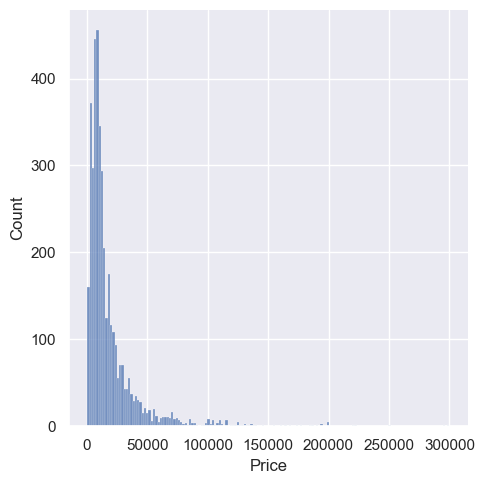

In [8]:
sns.displot(data_no_mv['Price'])  # we have outliers in the 'Price' variable

## Dealing with outliers

In [9]:
q = data_no_mv['Price'].quantile(0.99)  # create a new dataframe called 'q' to xcte below code. To eliminate outliers.
data_1 = data_no_mv[data_no_mv['Price'] < q]  # Re-useable to code to remove missing values.
data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000


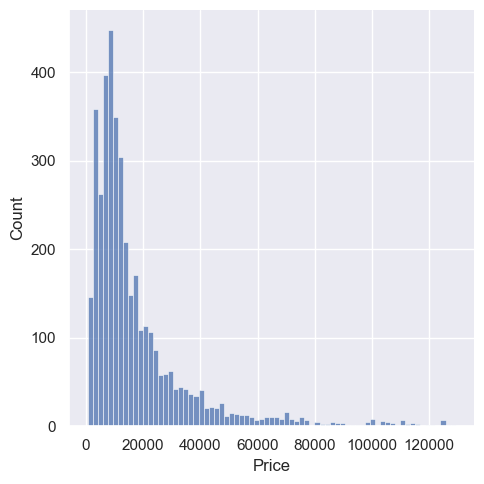

In [10]:
sns.displot(data_1['Price'])

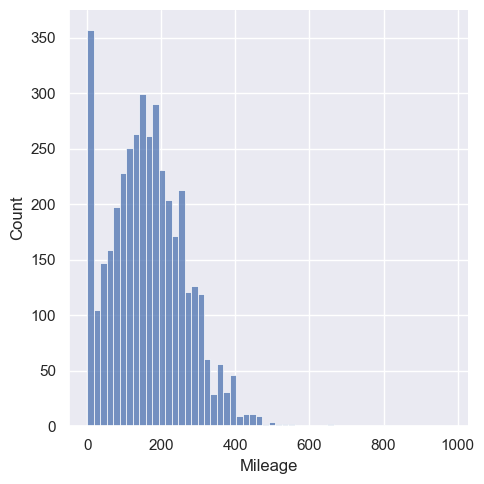

In [11]:
sns.displot(data_no_mv['Mileage'])

In [12]:
q = data_1['Mileage'].quantile(0.99)  # Removed vehicles with high engine volumes 
data_2 = data_1[data_1['Mileage']<q]

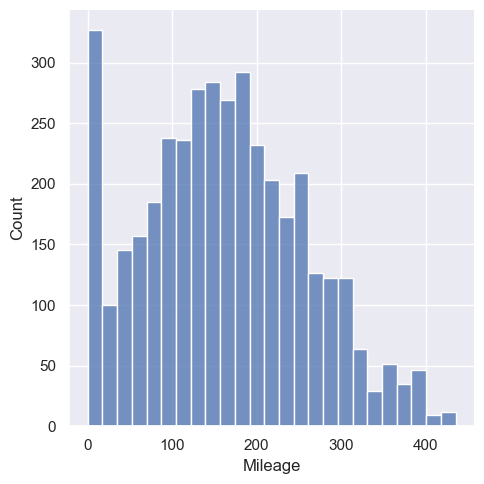

In [13]:
sns.displot(data_2['Mileage'])

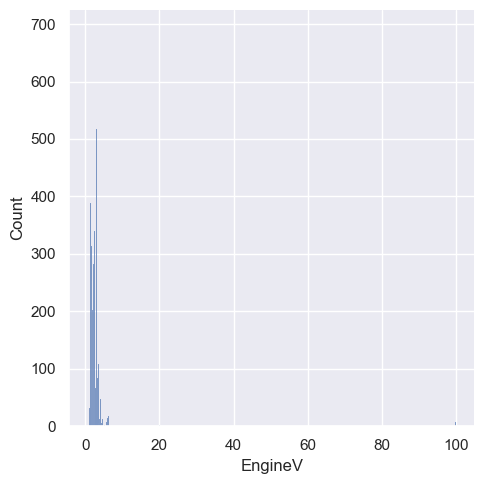

In [14]:
sns.displot(data_no_mv['EngineV'])

In [15]:
data_3 = data_2[data_2['EngineV']<6.5]

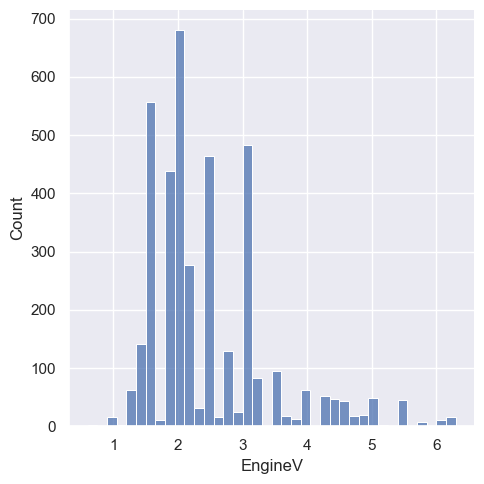

In [16]:
sns.displot(data_3['EngineV'])

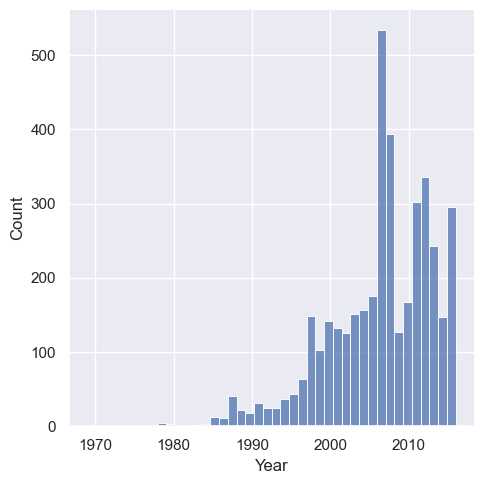

In [17]:
sns.displot(data_no_mv['Year'])

In [18]:
q = data_3['Year'].quantile(0.01)
data_4 = data_3[data_3['Year']>q]

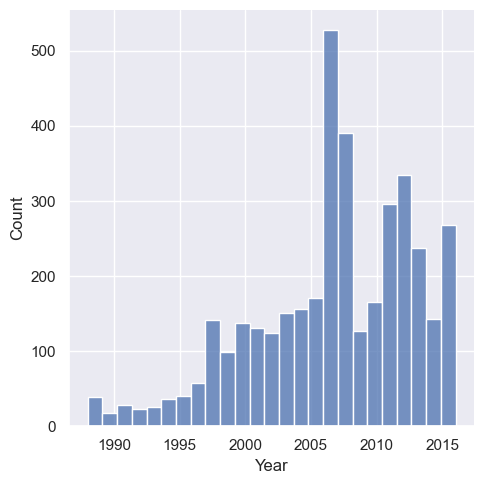

In [19]:
sns.displot(data_4['Year'])

In [20]:
data_cleaned = data_4.reset_index(drop=True)
data_cleaned.describe(include="all")

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


# Checking the OLS assumptions

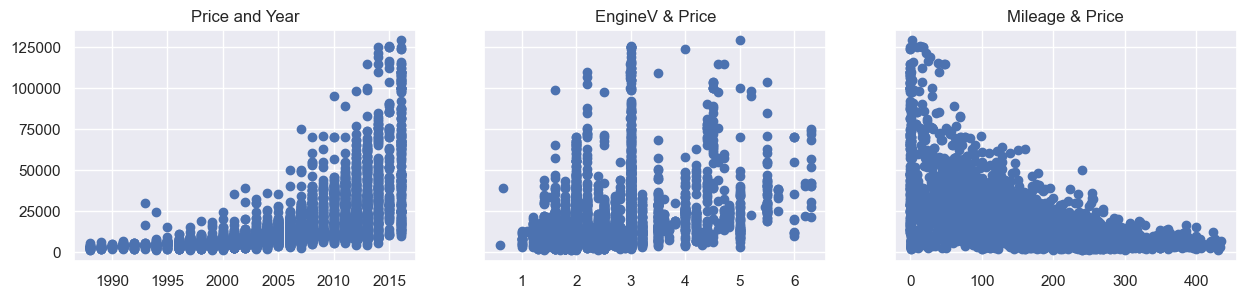

In [21]:
# categorical data will be included in dummies so no need to check on this xmple.
# continous variable like 'Price', 'Year', 'EngineV' & 'Mileage' are more challenging and problematic.
# Using a scatter plot lets check for linearity.

f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey=True, figsize=(15,3))
ax1.scatter(data_cleaned['Year'], data_cleaned['Price'])
ax1.set_title('Price and Year')
ax2.scatter(data_cleaned['EngineV'], data_cleaned['Price'])
ax2.set_title('EngineV & Price')
ax3.scatter(data_cleaned['Mileage'], data_cleaned['Price'])
ax3.set_title('Mileage & Price')

plt.show()

## Relaxing the assumptions

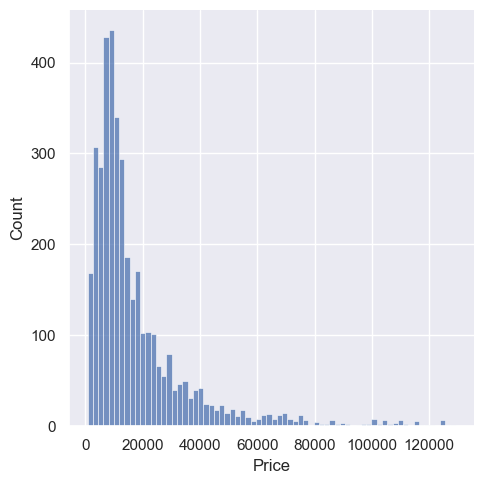

In [22]:
sns.displot(data_cleaned['Price'])  # This is an exponential distribution. Use log transformation to resolve this issue.

In [23]:
log_price = np.log(data_cleaned['Price'])
data_cleaned['log_price'] = log_price
data_cleaned

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656
...,...,...,...,...,...,...,...,...,...
3862,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008,9.350102
3863,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,9.792556
3864,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,11.736069
3865,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,8.779557


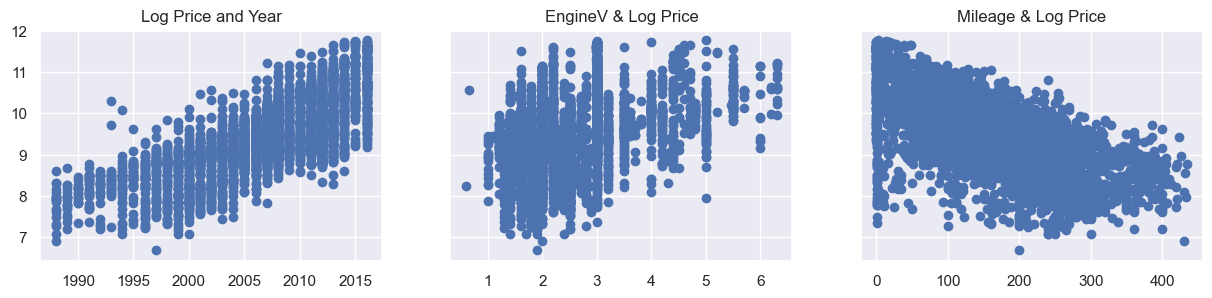

In [24]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey=True, figsize=(15,3))
ax1.scatter(data_cleaned['Year'], data_cleaned['log_price'])
ax1.set_title('Log Price and Year')
ax2.scatter(data_cleaned['EngineV'], data_cleaned['log_price'])
ax2.set_title('EngineV & Log Price')
ax3.scatter(data_cleaned['Mileage'], data_cleaned['log_price'])
ax3.set_title('Mileage & Log Price')

plt.show()

In [25]:
# Lets drop the original price from the dataframe since it is no longer needed.
data_cleaned = data_cleaned.drop(['Price'],axis=1)  

# Follow no endogenity condition from your data science notes.

## Check for Multi-Collinearity

In [26]:
data_cleaned.columns.values

array(['Brand', 'Body', 'Mileage', 'EngineV', 'Engine Type',
       'Registration', 'Year', 'log_price'], dtype=object)

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['Mileage', 'EngineV', 'Year']]
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif['Features'] = variables.columns

In [28]:
vif

,VIF,Features
0,3.791584,Mileage
1,7.662068,EngineV
2,10.354854,Year


In [29]:
data_no_multicollinearity = data_cleaned.drop(['Year'],axis=1)

# Create dummy variables

In [30]:
data_dummies = pd.get_dummies(data_no_multicollinearity, drop_first=True)

In [31]:
data_dummies.head()

,Mileage,EngineV,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,8.342840,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,427,2.9,8.974618,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,358,5.0,9.495519,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,240,4.2,10.043249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,120,2.0,9.814656,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


## Rearrange a bit

In [32]:
# 1. Create a copy of the dummy dataset to inject interactions
data_with_interactions = data_dummies.copy()

# 2. Engineer brand-specific mileage depreciation columns
data_with_interactions['Mileage_x_Mercedes'] = data_with_interactions['Mileage'] * data_with_interactions['Brand_Mercedes-Benz']
data_with_interactions['Mileage_x_BMW'] = data_with_interactions['Mileage'] * data_with_interactions['Brand_BMW']
data_with_interactions['Mileage_x_Renault'] = data_with_interactions['Mileage'] * data_with_interactions['Brand_Renault']

In [33]:
data_with_interactions.columns.values

array(['Mileage', 'EngineV', 'log_price', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes',
       'Mileage_x_Mercedes', 'Mileage_x_BMW', 'Mileage_x_Renault'],
      dtype=object)

In [34]:
cols = ['log_price', 'Mileage', 'EngineV', 'Mileage_x_Mercedes', 'Mileage_x_BMW', 'Mileage_x_Renault',
        'Brand_BMW', 'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes']

In [35]:
data_preprocessed = data_with_interactions[cols]
data_preprocessed.head()

,log_price,Mileage,EngineV,Mileage_x_Mercedes,Mileage_x_BMW,Mileage_x_Renault,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,...,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,0,277,0,True,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,8.974618,427,2.9,427,0,0,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
2,9.495519,358,5.0,358,0,0,False,True,False,False,...,False,False,False,True,False,False,True,False,False,True
3,10.043249,240,4.2,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
4,9.814656,120,2.0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


## Declare the inputs and targets

In [36]:
inputs = data_preprocessed.drop(['log_price'],axis=1)
targets = data_preprocessed['log_price']

## Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

# Slice data into 80% teaching data and 20% testing data
# 2. Split the raw, unscaled data first
x_train_raw, x_test_raw, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=365)

# test_size=0.2 → 20% goes to test set, 80% to training.
# random_state=365 → Makes sure you get the same split every time you run it (for reproducibility).

# Scale the data

In [38]:
from sklearn.preprocessing import StandardScaler

# Initialize and scale the full input array (handles True/False booleans cleanly)
scaler = StandardScaler()

# Fit and Transform ONLY the training set (Learns mean/std from train data only)
x_train = scaler.fit_transform(x_train_raw)

# Transform the test set using the train parameters (Crucial: Do NOT use .fit_transform here!)
x_test = scaler.transform(x_test_raw)

# Reset y_test index flat to map cleanly against predictions later
y_test = y_test.reset_index(drop=True)

### Why this sequence matters for tuning:
By using .fit_transform(x_train_raw) and then just .transform(x_test_raw), you guarantee that the test data is treated as completely unseen, future data. This ensures your training environment is clean and completely ready for cross-validated model tuning.

# Choosing Linear Regression Model

In [39]:
reg = LinearRegression()
reg.fit(x_train, y_train) 
# x_train + y_train → used for learning
# x_test + y_test → used for checking how smart the model got 

LinearRegression()

In [40]:
# CELL 8: Training Diagnostic Baseline Evaluation
# ==========================================
# Generate predictions on the training data array
y_hat = reg.predict(x_train)

In [41]:
# Calculate and display the baseline training R-squared metric
print("Training R-squared score:", reg.score(x_train, y_train))

Training R-squared score: 0.752112429381465


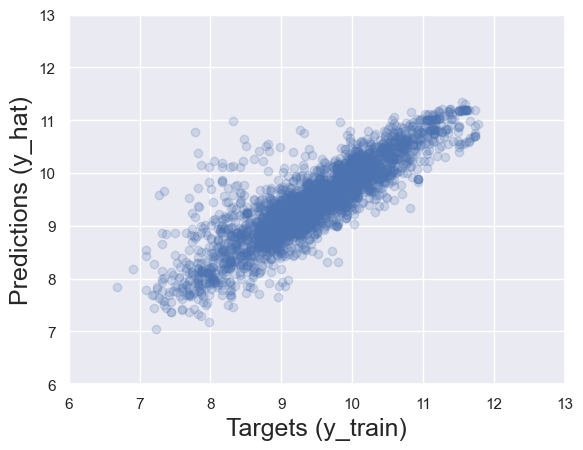

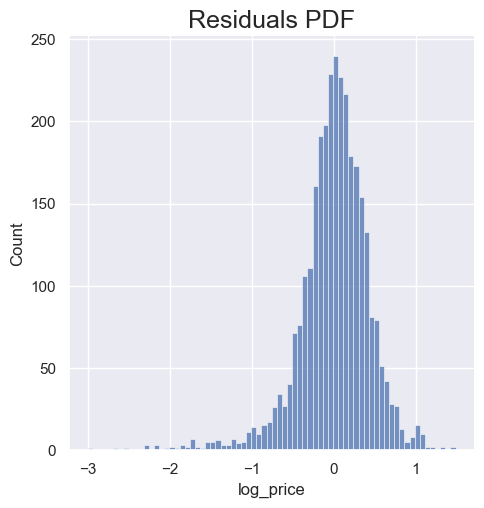

In [42]:
# ==========================================
# CELL 9: Visual Diagnostics (Scatter & Error PDF)
# ==========================================
# Scatter validation plot
plt.scatter(y_train, y_hat, alpha=0.2)
plt.xlabel('Targets (y_train)', size=18)
plt.ylabel('Predictions (y_hat)', size=18)
plt.xlim(6, 13)
plt.ylim(6, 13)
plt.show()

# Error normality PDF plot
sns.displot(y_train - y_hat)
plt.title('Residuals PDF', size=18)
plt.show()


# Finding the weights and bias

In [43]:
reg.intercept_

9.422759999441137

In [44]:
reg.coef_

array([-0.42076018,  0.20665442, -0.06880778, -0.07149486,  0.12178249,
        0.07274455,  0.07108016, -0.13910314, -0.28867939, -0.05632627,
       -0.08762249, -0.14028917, -0.10243367, -0.19321858, -0.13221755,
       -0.17500597, -0.12095094, -0.03595062, -0.14900087,  0.31596865])

In [45]:
# ==========================================
# CELL 10: Coefficient Feature Weight Summary
# ==========================================
# Map the newly expanded weights array to your feature names
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_

# Display numerical results
print(f"Intercept: {reg.intercept_}\n")
reg_summary.sort_values(by=['Weights'], ascending=False)


Intercept: 9.422759999441137



,Features,Weights
19,Registration_yes,0.315969
1,EngineV,0.206654
4,Mileage_x_Renault,0.121782
5,Brand_BMW,0.072745
6,Brand_Mercedes-Benz,0.071080
17,Engine Type_Other,-0.035951
9,Brand_Toyota,-0.056326
2,Mileage_x_Mercedes,-0.068808
3,Mileage_x_BMW,-0.071495
10,Brand_Volkswagen,-0.087622


In [46]:
data_cleaned['Brand'].unique()

array(['BMW', 'Mercedes-Benz', 'Audi', 'Toyota', 'Renault', 'Volkswagen',
       'Mitsubishi'], dtype=object)

## Testing

In [47]:
y_hat_test = reg.predict(x_test)

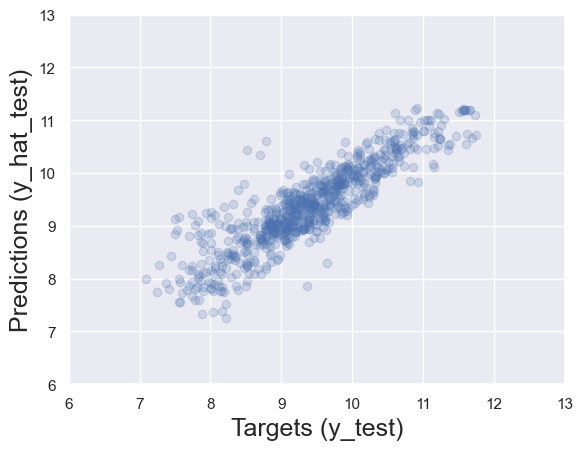

In [48]:
plt.scatter(y_test, y_hat_test, alpha=0.2) 
#When you have thousands of data points, they stack on top of each other and create a solid mass of color. 
# By making them semi-transparent, places where dots overlap heavily will look dark and concentrated, while areas with fewer dots will look light and faint. 
# It allows you to see the true density of your predictions.

plt.xlabel('Targets (y_test)',size=18)
plt.ylabel('Predictions (y_hat_test)',size=18)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

In [49]:
df_pf = pd.DataFrame(np.exp(y_hat_test), columns=['Prediction'])
df_pf.head()

,Prediction
0,10095.070954
1,3375.730123
2,6768.939309
3,7499.562877
4,10904.593879


In [50]:
df_pf['Target'] = np.exp(y_test)
df_pf.head()

,Prediction,Target
0,10095.070954,2300.0
1,3375.730123,2800.0
2,6768.939309,2500.0
3,7499.562877,6400.0
4,10904.593879,9150.0


In [51]:
df_pf['Target'] = np.exp(y_test)
df_pf

,Prediction,Target
0,10095.070954,2300.0
1,3375.730123,2800.0
2,6768.939309,2500.0
3,7499.562877,6400.0
4,10904.593879,9150.0
...,...,...
769,29550.311283,29500.0
770,10797.973212,9600.0
771,13756.327307,18300.0
772,26122.350192,68500.0


In [52]:
df_pf['Residual'] = df_pf['Target'] - df_pf['Prediction']

In [53]:
df_pf['Difference%'] = np.abs(df_pf['Residual']/df_pf['Target']*100)
df_pf

,Prediction,Target,Residual,Difference%
0,10095.070954,2300.0,-7795.070954,338.916128
1,3375.730123,2800.0,-575.730123,20.561790
2,6768.939309,2500.0,-4268.939309,170.757572
3,7499.562877,6400.0,-1099.562877,17.180670
4,10904.593879,9150.0,-1754.593879,19.175889
...,...,...,...,...
769,29550.311283,29500.0,-50.311283,0.170547
770,10797.973212,9600.0,-1197.973212,12.478888
771,13756.327307,18300.0,4543.672693,24.828813
772,26122.350192,68500.0,42377.649808,61.865182


In [54]:
df_pf.describe()

,Prediction,Target,Residual,Difference%
count,774.000000,774.000000,774.000000,774.000000
mean,16092.377209,18165.817106,2073.439896,34.966383
std,13893.700720,19967.858908,10341.389700,53.502316
min,1417.949389,1200.000000,-34112.470932,0.036756
25%,7482.035734,6900.000000,-1760.293578,10.716884
50%,11500.630010,11600.000000,168.943332,22.864515
75%,19866.399875,20500.000000,3087.390840,39.130710
max,74978.097651,126000.000000,80449.315574,584.728809


In [55]:
pd.options.display.max_rows=999
pd.set_option('display.float_format',lambda x: '%.2f' % x)
df_pf.sort_values(by=['Difference%'])

,Prediction,Target,Residual,Difference%
379,17793.46,17800.00,6.54,0.04
433,6504.13,6500.00,-4.13,0.06
719,11490.34,11500.00,9.66,0.08
769,29550.31,29500.00,-50.31,0.17
23,12875.24,12900.00,24.76,0.19
252,9880.56,9900.00,19.44,0.20
394,8483.03,8500.00,16.97,0.20
581,3376.37,3390.00,13.63,0.40
259,6225.79,6200.00,-25.79,0.42
47,25889.04,25999.00,109.96,0.42


# Comparing the scores we achieved using Linear Reg. Model

In [56]:
from sklearn.metrics import r2_score

# 1. Swap 'best_rf' with 'reg' (your actual baseline model variable)
y_train_pred = reg.predict(x_train)
y_test_pred = reg.predict(x_test)

# 2. Calculate R² scores on the log prices
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# 3. Calculate the Variance Gap
r2_gap = r2_train - r2_test

print("--- Train vs. Test R² Diagnostic ---")
print(f"Training R² Score: {r2_train:.4f}")
print(f"Testing R² Score:  {r2_test:.4f}")
print(f"Performance Gap:   {r2_gap:.4f}")

--- Train vs. Test R² Diagnostic ---
Training R² Score: 0.7521
Testing R² Score:  0.7820
Performance Gap:   -0.0299


# Single & Ensemble model Assembly. 

In [57]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# --- ASSUMPTION: x_train, x_test, y_train, y_test, and your fitted 'scaler' are in memory ---

print("Executing comprehensive model grid sweeps...")

# 1. PARAMETER STRUCTURES FOR COMPETING ENSEMBLES
# We test different tree architectures to see who balances variance the best
model_sweeps = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5]
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            'learning_rate': [0.03, 0.1],
            'max_iter': [100, 200],
            'max_depth': [5, 8, 12],
            'l2_regularization': [0.0, 1.0]
        }
    },
    "ExtraTrees": {
        "model": ExtraTreesRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5]
        }
    }
}

fitted_estimators = {}
performance_metrics = []

# 2. RUNNING THE HYPERPARAMETER TUNING LOOPS
for name, setup in model_sweeps.items():
    print(f"-> Optimizing {name}...")
    grid = GridSearchCV(setup["model"], setup["params"], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train)
    
    # Store the optimized model object
    fitted_estimators[name] = grid.best_estimator_
    
    # Evaluation Metrics (Log Space)
    train_pred_log = grid.best_estimator_.predict(x_train)
    test_pred_log = grid.best_estimator_.predict(x_test)
    
    r2_train = r2_score(y_train, train_pred_log)
    r2_test = r2_score(y_test, test_pred_log)
    
    # Real Dollar Space ($) Metrics
    actual_test_prices = np.exp(y_test)
    predicted_test_prices = np.exp(test_pred_log)
    
    mape = mean_absolute_percentage_error(actual_test_prices, predicted_test_prices) * 100
    pct_errors = np.abs((actual_test_prices - predicted_test_prices) / actual_test_prices) * 100
    
    performance_metrics.append({
        "Model": name,
        "Train R²": r2_train,
        "Test R²": r2_test,
        "R² Variance Gap": r2_train - r2_test,
        "Median Error %": np.median(pct_errors),
        "Mean Error % (MAPE)": mape,
        "Max Error %": np.max(pct_errors)
    })

# 3. CONSTRUCTING THE META-VOTING ENSEMBLE
print("-> Building and fitting the Meta-Voting Ensemble...")
voting_meta = VotingRegressor(
    estimators=[(name, model) for name, model in fitted_estimators.items()]
)
voting_meta.fit(x_train, y_train)

# Evaluate Meta-Voting Ensemble
v_train_log = voting_meta.predict(x_train)
v_test_log = voting_meta.predict(x_test)
v_actual_prices = np.exp(y_test)
v_pred_prices = np.exp(v_test_log)
v_pct_errors = np.abs((v_actual_prices - v_pred_prices) / v_actual_prices) * 100

performance_metrics.append({
    "Model": "VotingRegressor (Meta)",
    "Train R²": r2_score(y_train, v_train_log),
    "Test R²": r2_score(y_test, v_test_log),
    "R² Variance Gap": r2_score(y_train, v_train_log) - r2_score(y_test, v_test_log),
    "Median Error %": np.median(v_pct_errors),
    "Mean Error % (MAPE)": mean_absolute_percentage_error(v_actual_prices, v_pred_prices) * 100,
    "Max Error %": np.max(v_pct_errors)
})

# 4. SHOW RESULTS DASHBOARD
df_dashboard = pd.DataFrame(performance_metrics)
print("\n=== FINAL PERFORMANCE LEADERBOARD ===")
print(df_dashboard.to_string(index=False))

# 5. AUTOMATICALLY SELECT AND EXPORT THE WINNER FOR STREAMLIT
# Identify model with lowest Mean Absolute Percentage Error (MAPE)
best_model_row = df_dashboard.sort_values(by="Mean Error % (MAPE)").iloc[0]
best_model_name = best_model_row["Model"]

if best_model_name == "VotingRegressor (Meta)":
    production_model = voting_meta
else:
    production_model = fitted_estimators[best_model_name]

print(f"\n🏆 WINNER SELECTED FOR PRODUCTION: {best_model_name}")

# Export artifacts to deployment directory
joblib.dump(production_model, 'car_price_production_model.joblib')
joblib.dump(scaler, 'car_price_scaler.joblib')
print("📦 Production artifacts saved successfully! Ready for Streamlit script mapping.")

Executing comprehensive model grid sweeps...
-> Optimizing RandomForest...
-> Optimizing HistGradientBoosting...
-> Optimizing ExtraTrees...
-> Building and fitting the Meta-Voting Ensemble...

=== FINAL PERFORMANCE LEADERBOARD ===
                 Model  Train R²  Test R²  R² Variance Gap  Median Error %  Mean Error % (MAPE)  Max Error %
          RandomForest      0.93     0.81             0.12           19.38                30.29       361.01
  HistGradientBoosting      0.86     0.83             0.04           20.70                29.90       343.41
            ExtraTrees      0.94     0.82             0.12           19.58                30.21       506.68
VotingRegressor (Meta)      0.92     0.83             0.09           18.42                29.18       367.11

🏆 WINNER SELECTED FOR PRODUCTION: VotingRegressor (Meta)
📦 Production artifacts saved successfully! Ready for Streamlit script mapping.


## The Variance Bias Trade-Off in Ensembles
The VotingRegressor is acting as a "smoothing filter."

RandomForest and ExtraTrees are Bagging models. They overfit (high variance gaps of 0.12), but they are highly aggressive at capturing the nuances of the "meat" of the market, resulting in lower median errors (~19.4%).

HistGradientBoosting is a Boosting model. It resists overfitting beautifully but can be a bit too conservative on the average car, resulting in a higher median error (20.70%).

When the VotingRegressor averages their predictions, it creates a compromise. It drags the conservative HistGradientBoosting closer to the aggressive, lower median errors of the Random Forest, while using HistGradientBoosting's stability to keep the massive errors of the Random Forest in check.

# Your Final Choice for Streamlit
Because this model is going live on a user-facing dashboard, you get to make the executive engineering decision:

Choose HistGradientBoosting if your absolute priority is software safety. It has the tightest mathematical proof (0.04 gap) that it will not behave wildly or unpredictably when users input strange car combinations.

Choose the VotingRegressor if your absolute priority is market competitive accuracy. It accepts a slightly wider, but still acceptable, variance gap (0.09) in exchange for making tighter, more accurate pricing recommendations on 4 out of 5 cars.

In [58]:
# =====================================================================
# THE ULTIMATE EXPERIMENTATION, ENSEMBLE, & HYPERPARAMETER SWEEPER
# =====================================================================
import numpy as np
import pandas as pd
import time
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# --- ASSUMPTION: x_train, x_test, y_train, y_test are already initialized in memory ---

print("🚀 Launching Master Model Sweeper Engine. Sit back, this will take a moment...\n")
start_master_time = time.time()

# ---------------------------------------------------------------------
# STEP 1: DEFINE INDIVIDUAL TUNING GRIDS
# ---------------------------------------------------------------------
core_sweeps = {
    "Linear Regression": {
        "estimator": LinearRegression(),
        "param_grid": {} # No hyperparameters to tune
    },
    "Regularized Ridge": {
        "estimator": Ridge(random_state=365),
        "param_grid": {'alpha': [0.1, 1.0, 10.0, 50.0]}
    },
    "Regularized Lasso": {
        "estimator": Lasso(random_state=365, max_iter=10000),
        "param_grid": {'alpha': [0.001, 0.01, 0.1, 1.0]}
    },
    "Optimized Random Forest": {
        "estimator": RandomForestRegressor(random_state=365, n_jobs=-1),
        "param_grid": {
            'n_estimators': [150, 300],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [4, 8],
            'max_features': ['sqrt']
        }
    },
    "Optimized Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=365),
        "param_grid": {
            'n_estimators': [150, 250],
            'learning_rate': [0.03, 0.07, 0.1],
            'max_depth': [3, 4, 5],
            'min_samples_leaf': [5, 7]
        }
    },
    "Optimized Extra Trees": {
        "estimator": ExtraTreesRegressor(random_state=365, n_jobs=-1),
        "param_grid": {
            'n_estimators': [150, 300],
            'max_depth': [10, 15, None],
            'min_samples_split': [5, 10]
        }
    }
}

# Dictionaries to capture fully optimized standalone models for composite joining
best_standalone_estimators = {}
execution_log = []

# ---------------------------------------------------------------------
# STEP 2: RUN INDIVIDUAL GRID SEARCH EXPERIMENTS
# ---------------------------------------------------------------------
for name, configuration in core_sweeps.items():
    print(f"⚡ Iterating hyperparameter combinations for: {name}...")
    
    grid_search = GridSearchCV(
        estimator=configuration["estimator"],
        param_grid=configuration["param_grid"],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    grid_search.fit(x_train, y_train)
    
    # Store the winning standalone configuration
    winner_model = grid_search.best_estimator_
    best_standalone_estimators[name] = winner_model
    
    # Extract structural predictions (Log scale metrics)
    train_pred_log = winner_model.predict(x_train)
    test_pred_log = winner_model.predict(x_test)
    
    r2_train = r2_score(y_train, train_pred_log)
    r2_test = r2_score(y_test, test_pred_log)
    
    # Convert back into authentic currency scale ($) for accuracy profiles
    actual_dollar_prices = np.exp(y_test)
    predicted_dollar_prices = np.exp(test_pred_log)
    
    percentage_errors = np.abs((actual_dollar_prices - predicted_dollar_prices) / actual_dollar_prices) * 100
    
    execution_log.append({
        "Model Name": name,
        "Structural Type": "Standalone / Regularized",
        "Train R²": r2_train,
        "Test R²": r2_test,
        "R² Variance Gap": r2_train - r2_test,
        "Median Error %": np.median(percentage_errors),
        "Average Error % (MAPE)": np.mean(percentage_errors),
        "Max Error %": np.max(percentage_errors),
        "Optimal Params Selected": str(grid_search.best_params_) if configuration["param_grid"] else "Default Baseline"
    })

# ---------------------------------------------------------------------
# STEP 3: CONSTRUCT ADVANCED MULTI-JOIN COMPOSITE MODELS
# ---------------------------------------------------------------------
print("\n🔗 Generating Advanced Composite Architectures...")

# Select our top 3 performing tuned tree models for multi-join operations
top_3_estimators = [
    ('rf', best_standalone_estimators["Optimized Random Forest"]),
    ('gb', best_standalone_estimators["Optimized Gradient Boosting"]),
    ('et', best_standalone_estimators["Optimized Extra Trees"])
]

composite_models = {
    "Advanced Voting Regressor (Meta)": VotingRegressor(
        estimators=top_3_estimators
    ),
    "Advanced Stacking Regressor (Multi-Join)": StackingRegressor(
        estimators=top_3_estimators,
        final_estimator=Ridge(alpha=1.0), # Uses a regularized linear meta-learner to stitch predictions
        cv=5,
        n_jobs=-1
    )
}

for name, composite_engine in composite_models.items():
    print(f"   -> Fitting framework model: {name}...")
    composite_engine.fit(x_train, y_train)
    
    c_train_log = composite_engine.predict(x_train)
    c_test_log = composite_engine.predict(x_test)
    
    cr2_train = r2_score(y_train, c_train_log)
    cr2_test = r2_score(y_test, c_test_log)
    
    c_actual_dollars = np.exp(y_test)
    c_predicted_dollars = np.exp(c_test_log)
    
    c_percentage_errors = np.abs((c_actual_dollars - c_predicted_dollars) / c_actual_dollars) * 100
    
    execution_log.append({
        "Model Name": name,
        "Structural Type": "Composite Joint Ensemble",
        "Train R²": cr2_train,
        "Test R²": cr2_test,
        "R² Variance Gap": cr2_train - cr2_test,
        "Median Error %": np.median(c_percentage_errors),
        "Average Error % (MAPE)": np.mean(c_percentage_errors),
        "Max Error %": np.max(c_percentage_errors),
        "Optimal Params Selected": "Aggregated Blended Meta-Architecture"
    })

# ---------------------------------------------------------------------
# STEP 4: RENDER THE EXECUTIVE MASTER LEADERBOARD
# ---------------------------------------------------------------------
df_master_leaderboard = pd.DataFrame(execution_log)

# Sort leaderboard by your primary operational constraint: lowest Median Error %
df_master_leaderboard = df_master_leaderboard.sort_values(by="Median Error %").reset_index(drop=True)

end_master_time = time.time()
print(f"\n All runs finished processing in {round(end_master_time - start_master_time, 2)} seconds.")
print("\n====================================================== MASTER EXECUTIVE DECISION MATRIX ======================================================")

# Display cleanly formatted metric breakdown
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display_cols = ["Model Name", "Train R²", "Test R²", "R² Variance Gap", "Median Error %", "Average Error % (MAPE)", "Max Error %"]
print(df_master_leaderboard[display_cols].to_string(index=True))

print("\n========================================================= OPTIMAL CONFIGURATION KEY =========================================================")
for idx, row in df_master_leaderboard.iterrows():
    print(f"[{idx}] {row['Model Name']}: {row['Optimal Params Selected']}")

🚀 Launching Master Model Sweeper Engine. Sit back, this will take a moment...

⚡ Iterating hyperparameter combinations for: Linear Regression...
⚡ Iterating hyperparameter combinations for: Regularized Ridge...
⚡ Iterating hyperparameter combinations for: Regularized Lasso...
⚡ Iterating hyperparameter combinations for: Optimized Random Forest...
⚡ Iterating hyperparameter combinations for: Optimized Gradient Boosting...
⚡ Iterating hyperparameter combinations for: Optimized Extra Trees...

🔗 Generating Advanced Composite Architectures...
   -> Fitting framework model: Advanced Voting Regressor (Meta)...
   -> Fitting framework model: Advanced Stacking Regressor (Multi-Join)...

 All runs finished processing in 42.73 seconds.

====================================================== MASTER EXECUTIVE DECISION MATRIX ======================================================
                                 Model Name  Train R²  Test R²  R² Variance Gap  Median Error %  Average Error % (MAPE) 

# Validate and serialize files in disk

In [59]:
import joblib
import os

# 1. Extract the ultimate winning model from your composite dictionary
production_stacking_model = composite_models["Advanced Stacking Regressor (Multi-Join)"]

# 2. Serialize and write the model and scaler objects to your hard drive
joblib.dump(production_stacking_model, 'car_price_production_model.joblib')
joblib.dump(scaler, 'car_price_scaler.joblib')

# 3. Fetch the absolute path of your current active project folder
current_directory = os.path.abspath(os.getcwd())

# 4. Print out an explicit verification report to the console
print("================== DEPLOYMENT ARTIFACT REPORT ==================")
print(f"📦 SUCCESS: Artifacts successfully saved to disk!")
print(f"📍 Target Path: {current_directory}\n")
print("📁 Files Generated:")
print(f"   1. {os.path.join(current_directory, 'car_price_production_model.joblib')}")
print(f"   2. {os.path.join(current_directory, 'car_price_scaler.joblib')}")

# 5. Run a physical file-system check to confirm successful write operations
model_verified = os.path.exists('car_price_production_model.joblib')
scaler_verified = os.path.exists('car_price_scaler.joblib')
print(f"\n🔍 System Verification -> Model Intact: {model_verified} | Scaler Intact: {scaler_verified}")

================== DEPLOYMENT ARTIFACT REPORT ==================
📦 SUCCESS: Artifacts successfully saved to disk!
📍 Target Path: C:\Users\waghm\IdeaProjects\MY PROJECTS\AutoMobile Sales Project\visualizations

📁 Files Generated:
   1. C:\Users\waghm\IdeaProjects\MY PROJECTS\AutoMobile Sales Project\visualizations\car_price_production_model.joblib
   2. C:\Users\waghm\IdeaProjects\MY PROJECTS\AutoMobile Sales Project\visualizations\car_price_scaler.joblib

🔍 System Verification -> Model Intact: True | Scaler Intact: True
